In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZFeatureMap
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn.model_selection import train_test_split
import torch
import pytorch_lightning as pl


algorithm_globals.random_seed = 12345

/home/cappu/anaconda3/envs/quantumlib/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, OptionsV2 as Options, Session
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.primitives import Estimator
import numpy as np

In [3]:
def size_conv_layer(s : int, kernel_size : int, padding : int, stride : int) -> int:
        
        size = int(((s - kernel_size + 2 * padding)/stride) + 1)
        return size

In [4]:
def conv_circuit(params):
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1)
    target.cx(1, 0)
    target.rz(params[0], 0)
    target.ry(params[1], 1)
    target.cx(0, 1)
    target.ry(params[2], 1)
    target.cx(1, 0)
    target.rz(np.pi / 2, 0)
    return target


# Let's draw this circuit and see what it looks like
params = ParameterVector("θ", length=3)
circuit = conv_circuit(params)
#circuit.draw("mpl", style="clifford")

In [5]:
def conv_layer(num_qubits, param_prefix):
    qc = QuantumCircuit(num_qubits, name="Convolutional Layer")
    qubits = list(range(num_qubits))
    param_index = 0
    params = ParameterVector(param_prefix, length=num_qubits * 3)
    for q1, q2 in zip(qubits[0::2], qubits[1::2]):
        qc = qc.compose(conv_circuit(params[param_index : (param_index + 3)]), [q1, q2])
        qc.barrier()
        param_index += 3
    for q1, q2 in zip(qubits[1::2], qubits[2::2] + [0]):
        qc = qc.compose(conv_circuit(params[param_index : (param_index + 3)]), [q1, q2])
        qc.barrier()
        param_index += 3

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, qubits)
    return qc


circuit = conv_layer(4, "θ")
#circuit.decompose().draw("mpl", style="clifford")

In [6]:
def pool_circuit(params):
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1)
    target.cx(1, 0)
    target.rz(params[0], 0)
    target.ry(params[1], 1)
    target.cx(0, 1)
    target.ry(params[2], 1)

    return target


params = ParameterVector("θ", length=3)
circuit = pool_circuit(params)
#circuit.draw("mpl", style="clifford")

In [7]:
def pool_layer(sources, sinks, param_prefix):
    num_qubits = len(sources) + len(sinks)
    qc = QuantumCircuit(num_qubits, name="Pooling Layer")
    param_index = 0
    params = ParameterVector(param_prefix, length=num_qubits // 2 * 3)
    for source, sink in zip(sources, sinks):
        qc = qc.compose(pool_circuit(params[param_index : (param_index + 3)]), [source, sink])
        qc.barrier()
        param_index += 3

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, range(num_qubits))
    return qc


sources = [0, 1]
sinks = [2, 3]
circuit = pool_layer(sources, sinks, "θ")
#circuit.decompose().draw("mpl", style="clifford")

In [8]:
def get_least_busy_backend(service, min_qubits=4):
    """
    Get the least busy backend that meets the minimum qubit requirement.
    
    Args:
        service: QiskitRuntimeService instance
        min_qubits (int): Minimum number of qubits required
    
    Returns:
        str: Name of the least busy backend
    """
    backends = service.backends()
    
    # Filter backends based on criteria
    filtered_backends = []
    for backend in backends:
        # Check if backend meets our requirements
        if (backend.status().operational and  # Backend is operational
            backend.status().pending_jobs is not None and  # Queue information is available
            backend.num_qubits >= min_qubits):  # Has enough qubits
            filtered_backends.append(backend)
    
    if not filtered_backends:
        raise ValueError(f"No available backend with at least {min_qubits} qubits")
    
    # Sort by number of pending jobs
    least_busy = sorted(filtered_backends, 
                       key=lambda x: x.status().pending_jobs)[0]
    
    return least_busy.name


In [9]:
from qiskit.circuit.library import ZFeatureMap
from qiskit.circuit.library import PauliFeatureMap

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Estimator as Estimator


def create_qnn():
    # Definiamo la feature map con ZFeatureMap per 4 qubit
    #feature_map = ZFeatureMap(4)
    feature_map = PauliFeatureMap(4,1)
    # Definizione del circuito convolutivo quantistico
    ansatz = QuantumCircuit(4)
    ansatz.compose(conv_layer(4, "c1"), list(range(4)), inplace=True)
    ansatz.compose(pool_layer([0, 1], [2, 3], "p1"), list(range(4)), inplace=True)
    ansatz.compose(conv_layer(2, "c2"), list(range(2)), inplace=True)
    ansatz.compose(pool_layer([0], [1], "p2"), list(range(2)), inplace=True)

    # Creazione del circuito finale
    circuit = QuantumCircuit(4)
    circuit.compose(feature_map, range(4), inplace=True)
    circuit.compose(ansatz, range(4), inplace=True)

    # Definizione dell'osservabile Z su 1 qubit rimanente
    observable = SparsePauliOp.from_list([("Z" + "I" * 3, 1)])
    exact_estimator = Estimator()
# The circuit needs to be transpiled to the AerSimulator target
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    isa_circuit = pass_manager.run(circuit)
    qnn = EstimatorQNN(
    circuit=isa_circuit,
    estimator=exact_estimator,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    input_gradients=True
    )
    '''
    # Creazione di EstimatorQNN
    qnn = EstimatorQNN(
        circuit=circuit.decompose(),
        observables=observable,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True
    )
    '''
    
    return qnn
from qiskit_machine_learning.connectors import TorchConnector

# Crea il Quantum Neural Network
qnn = create_qnn()

# Connettore per PyTorch
qnn_connector = TorchConnector(qnn)


/tmp/ipykernel_217189/3410855199.py:57: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  qnn = create_qnn()
/tmp/ipykernel_217189/3410855199.py:57: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  qnn = create_qnn()


In [10]:
import torch
import numpy as np
from qiskit_machine_learning.connectors import TorchConnector

def quanv(image_batch, qnn):
    """
    Applica la quanvolution su un batch di immagini con più canali utilizzando un quantum neural network (qnn)
    con TorchConnector.
    
    :param image_batch: batch di immagini di forma (batch_size, channels, h, w)
    :param qnn: il quantum neural network con TorchConnector
    :return: batch di immagini con l'applicazione della quanvolution di forma (batch_size, channels, h//2, w//2)
    """
    batch_size, channels, h, w = image_batch.shape

    # Inizializza l'output con la dimensione corretta, mantenendo lo stesso numero di canali
    out = torch.zeros((batch_size, channels, h // 2, w // 2), device=image_batch.device)

    # Loop sugli esempi del batch
    for b in range(batch_size):
        for c in range(channels):  # Loop sui canali
            image = image_batch[b, c]  # Estrai il canale corrente
            for j in range(0, h, 2):  # Scorre lungo l'altezza con passi di 2
                for k in range(0, w, 2):  # Scorre lungo la larghezza con passi di 2
                    # Estrai il blocco 2x2
                    block = image[j:j+2, k:k+2]
                    
                    if block.shape == (2, 2):  # Verifica che il blocco sia 2x2
                        # Flatten il blocco in un vettore
                        block_vector = block.flatten().unsqueeze(0).float()  # Trasforma in tensore e aggiungi batch dimension
                        
                        # Applica il quantum neural network (qnn) con TorchConnector
                        block_output = qnn(block_vector)

                        # Inserisci il risultato nel tensore di output per il canale corrente
                        out[b, c, j // 2, k // 2] = block_output.item()

    return out

In [11]:
import torch
import pytorch_lightning as pl

class HybridLeNet5(torch.nn.Module):
    
    def __init__(self, in_shape: tuple, ou_dim: int) -> None:
        super().__init__()
        if len(in_shape) != 3:
            raise Exception(f"The parameter in_shape must be a tuple of three elements (channels, width, height), found {in_shape}")
        if ou_dim < 1:
            raise Exception(f"The parameter ou_dim must be greater than 1, found {ou_dim}")
        
        c, w, h = in_shape
        c1 = 6
        self.conv_1 = torch.nn.Conv2d(in_channels=c, out_channels=c1, kernel_size=5, padding=2, stride=1)
        w1 = size_conv_layer(w, kernel_size=5, padding=2, stride=1)
        h1 = size_conv_layer(h, kernel_size=5, padding=2, stride=1)
        
        self.max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        w2 = size_conv_layer(w1, kernel_size=2, padding=0, stride=2)
        h2 = size_conv_layer(h1, kernel_size=2, padding=0, stride=2)
        
        c2 = 6
        self.conv_2 = torch.nn.Conv2d(in_channels=c1, out_channels=c2, kernel_size=5, stride=1)
        w3 = size_conv_layer(w2, kernel_size=5, padding=0, stride=1)
        h3 = size_conv_layer(h2, kernel_size=5, padding=0, stride=1)

        self.max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        w4 = size_conv_layer(w3, kernel_size=2, padding=0, stride=2)
        h4 = size_conv_layer(h3, kernel_size=2, padding=0, stride=2)
        
        self.qnn_connector = qnn_connector
        # Calcolo della dimensione del flatten per i fully connected layers
        self.flatten_size = 7 * 7 * 6
        fc_2_size = int(self.flatten_size * 30 / 100)

        self.fc_1 = torch.nn.Linear(self.flatten_size, fc_2_size)
        self.fc_2 = torch.nn.Linear(fc_2_size, ou_dim)

        self.relu = torch.nn.ReLU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.cuda.amp.autocast():  # Abilita l'uso di mixed-precision su GPU
            x = self.max_pool1(self.relu(self.conv_1(x)))
            x = self.max_pool2(self.relu(self.conv_2(x)))
            x = quanv(x, self.qnn_connector)
            x = x.view(-1, self.flatten_size)
        #print(self.flatten_size)
        #print(f"Dimensione di x prima di fc_1: {x.shape}")  # Dovrebbe essere (64, 196)

            x = self.relu(self.fc_1(x))

        
        # Output layer
            x = self.fc_2(x)
    
        return x

In [12]:
import torch
import pytorch_lightning as pl

class HybridLeNet5(torch.nn.Module):
    
    def __init__(self, in_shape: tuple, ou_dim: int) -> None:
        super().__init__()
        if len(in_shape) != 3:
            raise Exception(f"The parameter in_shape must be a tuple of three elements (channels, width, height), found {in_shape}")
        if ou_dim < 1:
            raise Exception(f"The parameter ou_dim must be greater than 1, found {ou_dim}")
        
        c, w, h = in_shape
        c1 = 6
        self.conv_1 = torch.nn.Conv2d(in_channels=c, out_channels=c1, kernel_size=5, padding=2, stride=1)
        w1 = size_conv_layer(w, kernel_size=5, padding=2, stride=1)
        h1 = size_conv_layer(h, kernel_size=5, padding=2, stride=1)
        
        self.max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        w2 = size_conv_layer(w1, kernel_size=2, padding=0, stride=2)
        h2 = size_conv_layer(h1, kernel_size=2, padding=0, stride=2)
        
        c2 = 6
        self.conv_2 = torch.nn.Conv2d(in_channels=c1, out_channels=c2, kernel_size=5, stride=1)
        w3 = size_conv_layer(w2, kernel_size=5, padding=0, stride=1)
        h3 = size_conv_layer(h2, kernel_size=5, padding=0, stride=1)

        self.max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        w4 = size_conv_layer(w3, kernel_size=2, padding=0, stride=2)
        h4 = size_conv_layer(h3, kernel_size=2, padding=0, stride=2)
        
        self.qnn_connector = qnn_connector
        # Calcolo della dimensione del flatten per i fully connected layers
        self.flatten_size = 7 * 7 * 6
        fc_2_size = int(self.flatten_size * 30 / 100)

        self.fc_1 = torch.nn.Linear(self.flatten_size, fc_2_size)
        self.fc_2 = torch.nn.Linear(fc_2_size, ou_dim)

        self.relu = torch.nn.ReLU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.cuda.amp.autocast():  # Abilita l'uso di mixed-precision su GPU
            x = self.max_pool1(self.relu(self.conv_1(x)))
            x = self.max_pool2(self.relu(self.conv_2(x)))
            x = quanv(x, self.qnn_connector)
            x = x.view(-1, self.flatten_size)
        #print(self.flatten_size)
        #print(f"Dimensione di x prima di fc_1: {x.shape}")  # Dovrebbe essere (64, 196)

            x = self.relu(self.fc_1(x))

        
        # Output layer
            x = self.fc_2(x)
    
        return x

In [13]:
class HybridNet(pl.LightningModule):
    def __init__(self):
        super(HybridNet, self).__init__()
        
        # Instantiate the quantum convolution layer (3x3 kernel assumed)
        #self.quanv_layer = QuanvolutionLayer()

        # Initialize the HybridLeNet5 model with quantum convolution
        self.network = HybridLeNet5(in_shape=(3, 64, 64), ou_dim=2)

        # Define the loss function (Cross Entropy for classification)
        self.loss = torch.nn.CrossEntropyLoss()
    def forward(self, x):
        return self.network.forward(x)

        
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)

        #print(labels, outputs)

        loss      = self.loss(outputs, labels)
        # For example, log accuracy
        _, predicted = torch.max(outputs.data, 1)
        accuracy = torch.sum(predicted == labels.data).item() / labels.size(0)

        # Logging info
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_accuracy', accuracy, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.loss(outputs, labels)

        # Compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        accuracy = torch.sum(predicted == labels.data).item() / labels.size(0)

        # Logging info
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_accuracy', accuracy, on_epoch=True, prog_bar=True)
        
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.0001)
        
        # Define the StepLR scheduler to reduce the learning rate every 5 epochs
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
        return [optimizer], [scheduler]

In [14]:
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl
import torch
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

In [15]:
from metrics import MetricsLogger
from dataio.loader import EuroSATDataModule
from metrics import MetricsLogger

In [16]:
# Definisco i paths delle mie directory
base_path = "./"
dataset_path = os.path.join(base_path, "dataset")
train_dir = os.path.join(dataset_path, "training")
val_dir = os.path.join(dataset_path, "validation")
new_run_name = "run_32"
data_module = EuroSATDataModule(train_dir=train_dir, val_dir=val_dir,batch_size=32, num_workers=16,reduce_by_half = True)
# Definizione del logger per TensorBoard
log_dir = os.path.join(base_path, 'lightning_logs_quanv', new_run_name, 'EuroSATClassifier')
checkpoint_dir = os.path.join(base_path, 'saved_models_quanv', new_run_name, 'classifiers')
tb_logger = pl.loggers.TensorBoardLogger(log_dir)
if not os.path.exists(log_dir):
    os.makedirs(log_dir)
# Definizione del callback per salvare il modello
checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join('saved_models_quanv', 'classifiers'),
    filename='EuroSATClassifier',
    monitor='val_loss',
    save_top_k=1,
    mode='min',
)
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Inizializza il callback per tracciare le metriche
metrics_logger = MetricsLogger(log_dir=log_dir)
model = HybridNet()
#model = torch.compile(HybridNet())

#model.to(device)
from pytorch_lightning.strategies import DDPStrategy

In [17]:
print(val_dir)

./dataset/validation


In [18]:
#trainer = pl.Trainer(
 #   max_epochs=5,
  #  callbacks=[checkpoint_callback, metrics_logger],
   # logger=tb_logger,
    #accelerator='gpu', 
    #devices=[0],
    #devices=2,
    #precision=16  # Enable mixed precision training
    #)

#import tensorflow as tf
#with tf.device('/GPU:0'):
   # trainer.fit(model, data_module)
    

In [19]:
#from lightning.pytorch.accelerators import find_usable_cuda_devices

# Find two GPUs on the system that are not already occupied
trainer = pl.Trainer(max_epochs=5,
    callbacks=[checkpoint_callback, metrics_logger],
    logger=tb_logger,
    accelerator="cuda",
    devices=[0]
    )
#from lightning.fabric import Fabric

#from lightning.fabric.accelerators import find_usable_cuda_devices


# Works with Fabric too
#fabric = Fabric(accelerator="cuda", devices=find_usable_cuda_devices(2))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [20]:
#devices=find_usable_cuda_devices(2)
#print (devices)

In [25]:
with torch.cuda.amp.autocast():
    trainer.fit(model, data_module)


# Estrazione delle metriche salvate dal metrics_logger
train_losses = metrics_logger.train_losses
val_losses = metrics_logger.val_losses
train_accuracies = metrics_logger.train_accuracies
val_accuracies = metrics_logger.val_accuracies

# Stampa delle metriche
print("Train Losses:", train_losses)
print("Validation Losses:", val_losses)
print("Train Accuracies:", train_accuracies)
print("Validation Accuracies:", val_accuracies)

/tmp/ipykernel_217189/73935255.py:1: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast('cuda'):


TypeError: set_autocast_enabled(): argument 'enabled' (position 2) must be bool, not str

Dati caricati dal CSV:
   epoch  train_loss  val_loss  train_accuracy  val_accuracy
0      0         NaN  0.694092             NaN      0.421875
1      0         NaN  0.675365             NaN      0.886667
2      1     0.68554  0.643151         0.76875      0.893333


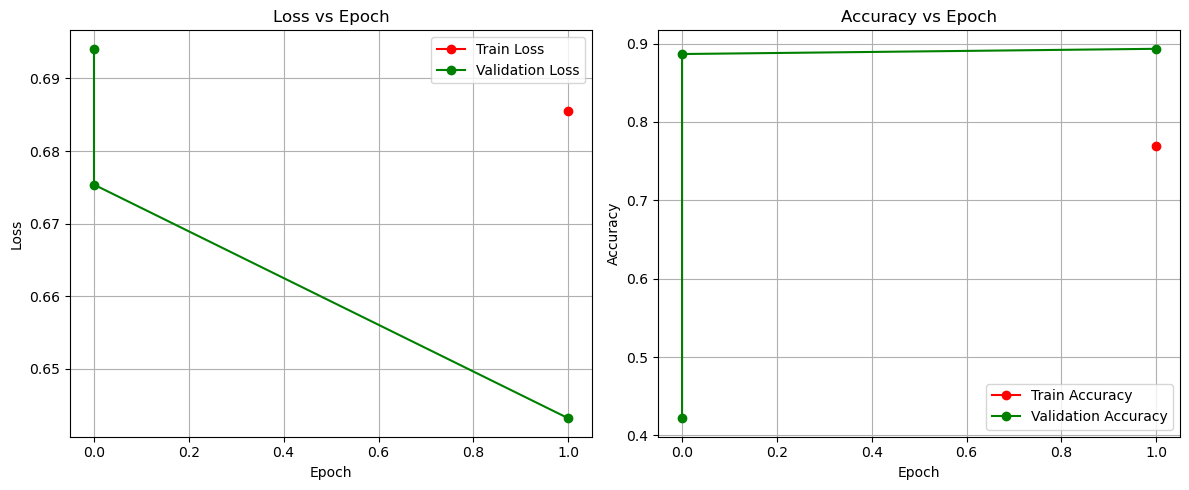

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Carica i dati dal CSV
csv_path = os.path.join(log_dir, 'metrics.csv')
df = pd.read_csv(csv_path)

# Stampa per controllo
print("Dati caricati dal CSV:")
print(df.head())

# Lista delle epoche per i grafici
epochs = df['epoch'].tolist()

# Plot della Loss (Train e Validation) in funzione delle epoche con marker
plt.figure(figsize=(12, 5))

# Grafico della Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, df['train_loss'], label='Train Loss', marker='o', color='red')
plt.plot(epochs, df['val_loss'], label='Validation Loss', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)

# Plot della Accuratezza (Train e Validation) in funzione delle epoche con marker
plt.subplot(1, 2, 2)
plt.plot(epochs, df['train_accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(epochs, df['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)

# Mostra i grafici
plt.tight_layout()
plt.show()


In [23]:
#calcolo max e min accuraratezza/loss
max_train_accuracy = max(train_accuracies)
min_train_loss = min(train_losses)
max_val_accuracy = max(val_accuracies[:len(epochs)])  # Considera solo i valori corrispondenti alle epoche effettive
min_val_loss = min(val_losses[:len(epochs)])  # Considera solo i valori corrispondenti alle epoche effettive

print("Massimo dell'accuratezza di training:", max_train_accuracy)
print("Minimo della loss di training:", min_train_loss)
print("Massimo dell'accuratezza di validazione:", max_val_accuracy)
print("Minimo della loss di validazione:", min_val_loss)

Massimo dell'accuratezza di training: 0.8974999785423279
Minimo della loss di training: 0.6595572829246521
Massimo dell'accuratezza di validazione: 0.8933333158493042
Minimo della loss di validazione: 0.643151044845581
